## Step 1: Data Collection & Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/Users/durgaprasad/Downloads/neo.csv')

In [4]:
df

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


## Step 2: Initial Data Inspection

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  str    
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  str    
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), str(2)
memory usage: 7.1 MB


In [7]:
df.shape

(90836, 10)

In [8]:
df.columns

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='str')

In [9]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [10]:
df.tail()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False
90835,54205447,(2021 TW7),0.039862,0.089133,27024.455553,5.977213e+07,Earth,False,24.12,False


In [11]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [12]:
df.dtypes

id                      int64
name                      str
est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
orbiting_body             str
sentry_object            bool
absolute_magnitude    float64
hazardous                bool
dtype: object

In [13]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

id: 27423 unique values
name: 27423 unique values
est_diameter_min: 1638 unique values
est_diameter_max: 1638 unique values
relative_velocity: 90828 unique values
miss_distance: 90536 unique values
orbiting_body: 1 unique values
sentry_object: 1 unique values
absolute_magnitude: 1638 unique values
hazardous: 2 unique values


In [14]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                    Missing Count  Missing %
id                              0        0.0
name                            0        0.0
est_diameter_min                0        0.0
est_diameter_max                0        0.0
relative_velocity               0        0.0
miss_distance                   0        0.0
orbiting_body                   0        0.0
sentry_object                   0        0.0
absolute_magnitude              0        0.0
hazardous                       0        0.0


In [15]:
duplicates = df.duplicated().sum()

In [16]:
duplicates

np.int64(0)

In [17]:
df['hazardous'].value_counts()

hazardous
False    81996
True      8840
Name: count, dtype: int64

In [18]:
df['hazardous'].value_counts(normalize=True) * 100

hazardous
False    90.268176
True      9.731824
Name: proportion, dtype: float64

## Step 3: Data Cleaning

In [20]:
df_clean = df.copy()

In [21]:
df_clean

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


In [22]:
df_clean['orbiting_body'].unique()

<ArrowStringArray>
['Earth']
Length: 1, dtype: str

In [23]:
df_clean['sentry_object'].unique()

array([False])

In [24]:
cols_to_drop = ['id', 'name', 'orbiting_body', 'sentry_object']
df_clean.drop(columns=cols_to_drop, inplace=True)

In [25]:
df_clean.shape

(90836, 6)

In [26]:
cols_to_drop

['id', 'name', 'orbiting_body', 'sentry_object']

In [27]:
df_clean.columns

Index(['est_diameter_min', 'est_diameter_max', 'relative_velocity',
       'miss_distance', 'absolute_magnitude', 'hazardous'],
      dtype='str')

In [28]:
df_clean['hazardous'] = df_clean['hazardous'].astype(int)
print(df_clean.dtypes)

est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
absolute_magnitude    float64
hazardous               int64
dtype: object


In [29]:
df_clean

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1
...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,25.00,0
90832,0.016771,0.037501,46114.605073,5.432121e+07,26.00,0
90833,0.031956,0.071456,7566.807732,2.840077e+07,24.60,0
90834,0.007321,0.016370,69199.154484,6.869206e+07,27.80,0


In [30]:
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Removed {before - after} duplicate rows')
print(f'Clean dataset shape: {df_clean.shape}')

Removed 7 duplicate rows
Clean dataset shape: (90829, 6)


In [31]:
df_clean

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1
...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,25.00,0
90832,0.016771,0.037501,46114.605073,5.432121e+07,26.00,0
90833,0.031956,0.071456,7566.807732,2.840077e+07,24.60,0
90834,0.007321,0.016370,69199.154484,6.869206e+07,27.80,0


## Step 4: Exploratory Data Analysis (EDA)

### 4.1 Univariate Analysis — Distribution Plots

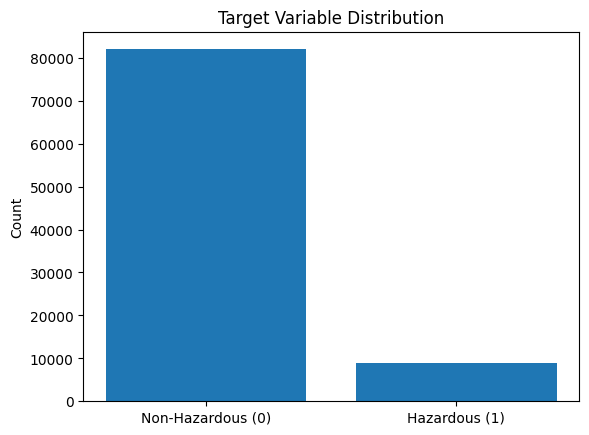

In [34]:
plt.bar(['Non-Hazardous (0)', 'Hazardous (1)'],
            df_clean['hazardous'].value_counts().values)
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.show()

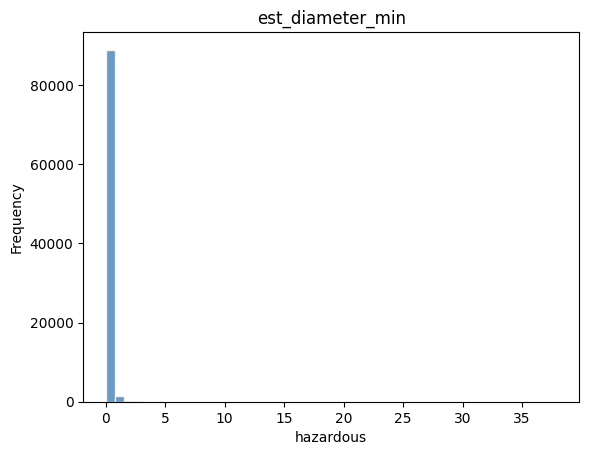

In [35]:
plt.hist(df_clean["est_diameter_min"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.title("est_diameter_min")
plt.xlabel(col)
plt.ylabel('Frequency')
plt.show()

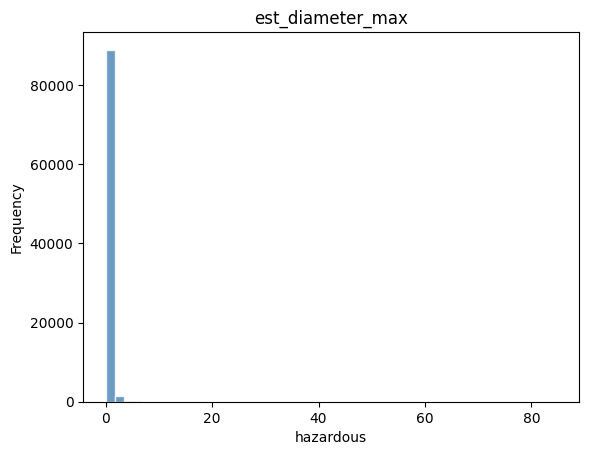

In [36]:
plt.hist(df_clean["est_diameter_max"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.title("est_diameter_max")
plt.xlabel(col)
plt.ylabel('Frequency')
plt.show()

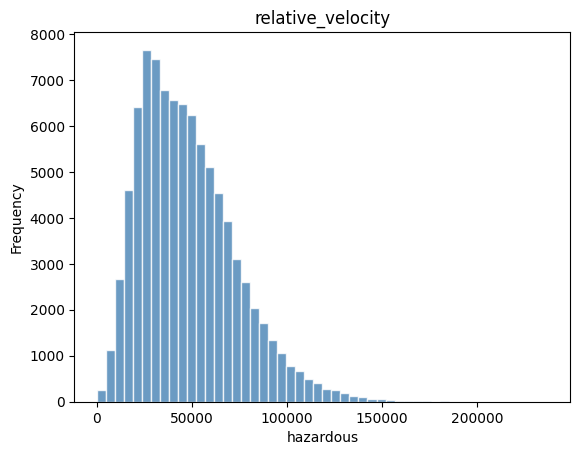

In [37]:
plt.hist(df_clean["relative_velocity"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.title("relative_velocity")
plt.xlabel(col)
plt.ylabel('Frequency')
plt.show()

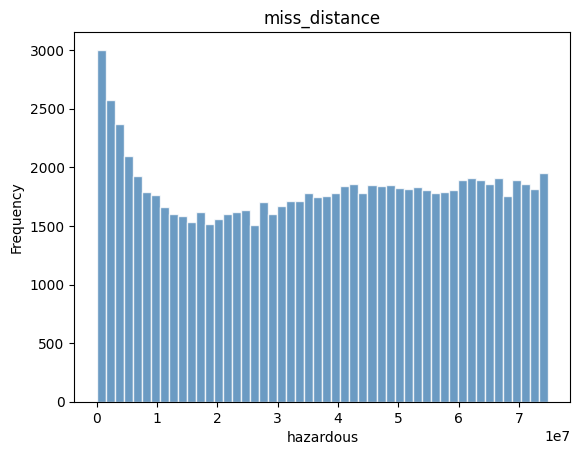

In [38]:
plt.hist(df_clean["miss_distance"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.title("miss_distance")
plt.xlabel(col)
plt.ylabel('Frequency')
plt.show()

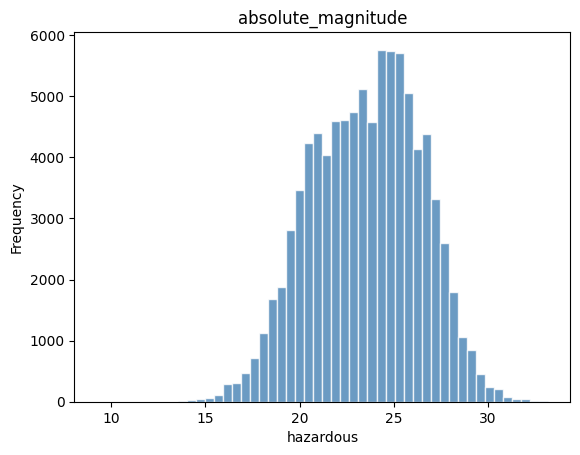

In [39]:
plt.hist(df_clean["absolute_magnitude"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.title("absolute_magnitude")
plt.xlabel(col)
plt.ylabel('Frequency')
plt.show()

### Observation: Most features are right-skewed — log transformation may help

### 4.2 Bivariate Analysis — Feature vs Target

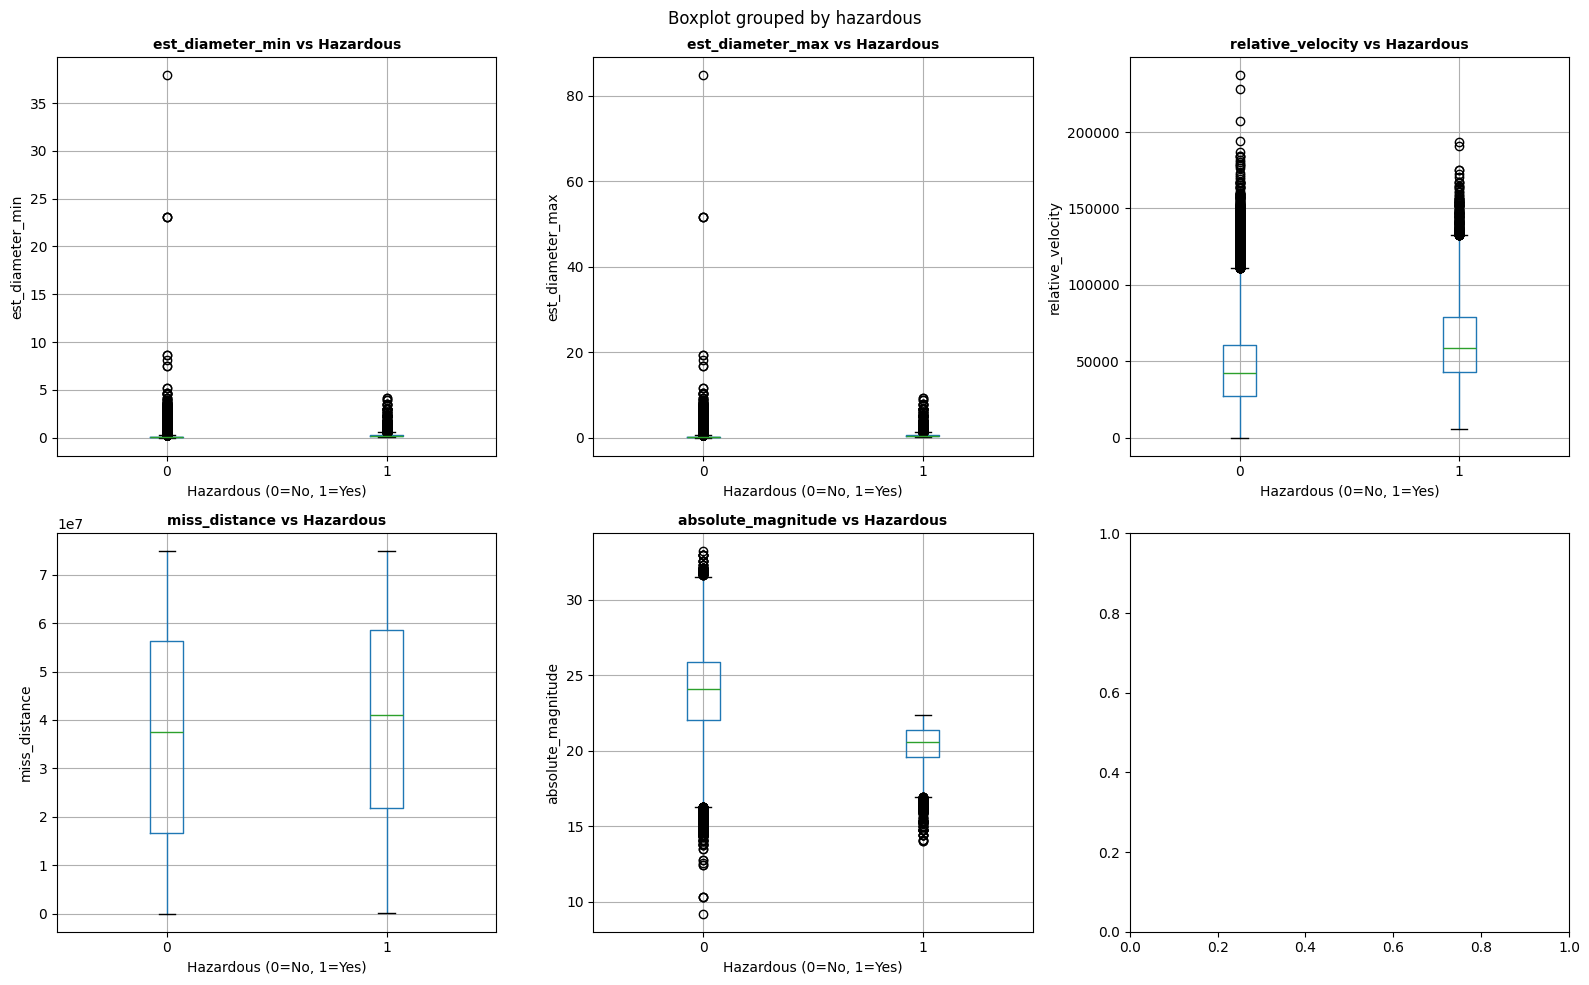

In [41]:
numerical_cols = ['est_diameter_min', 'est_diameter_max', 'relative_velocity',
                  'miss_distance', 'absolute_magnitude']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df_clean.boxplot(column=col, by='hazardous', ax=axes[i])
    axes[i].set_title(f'{col} vs Hazardous', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Hazardous (0=No, 1=Yes)')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

### 4.3 Multivariate Analysis — Correlation Heatmap & Pairplot

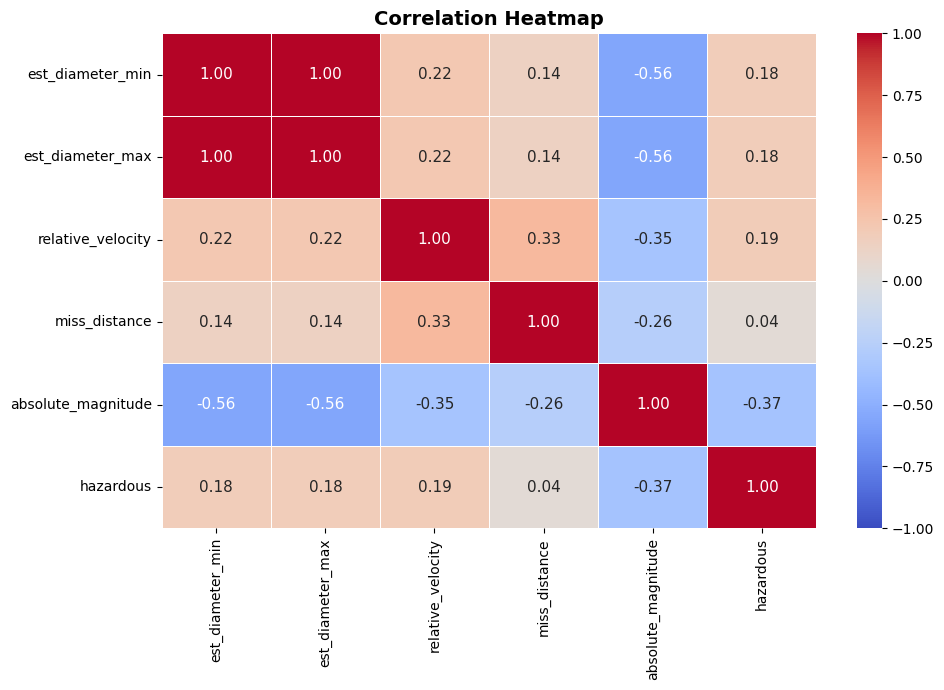

In [43]:
plt.figure(figsize=(10, 7))
corr_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

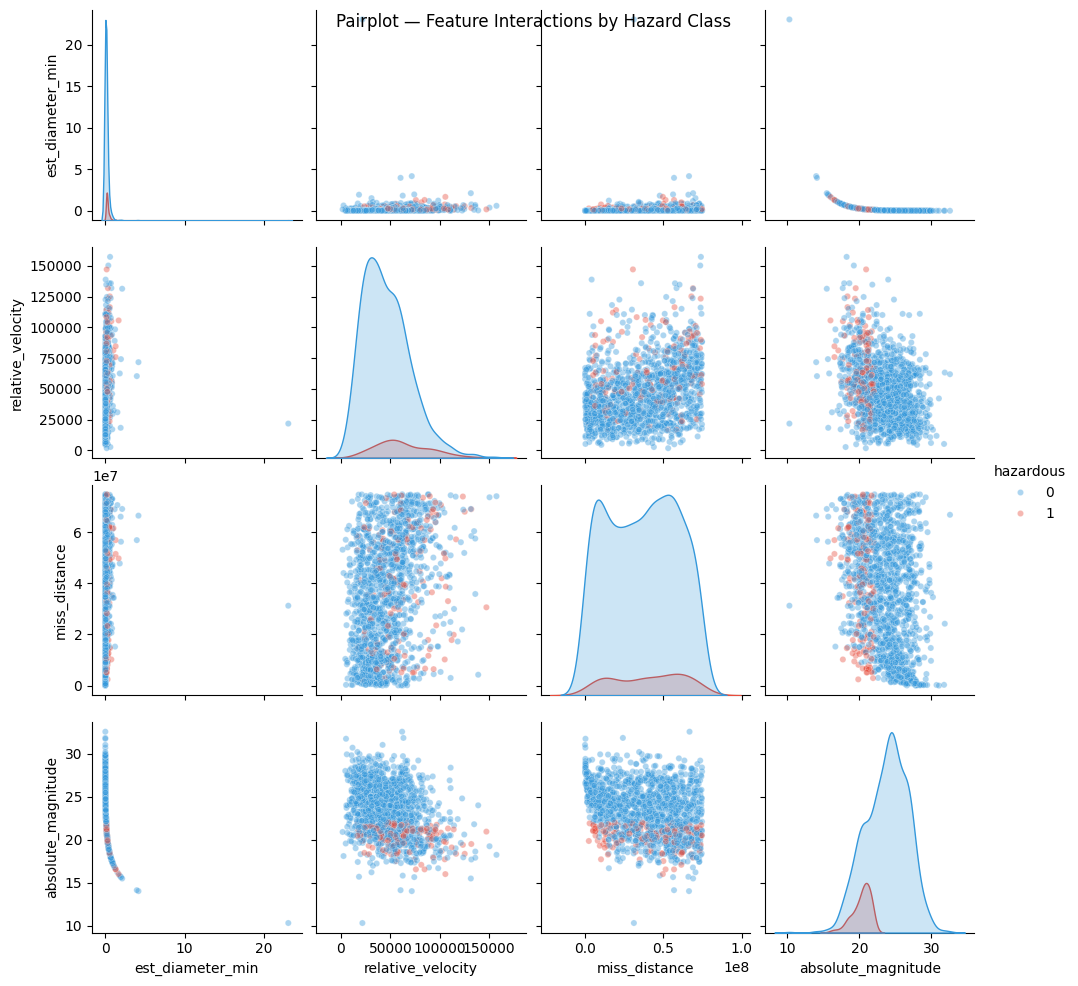

In [44]:
sample_df = df_clean.sample(n=1500, random_state=42)
pair_cols = ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']

g = sns.pairplot(sample_df[pair_cols], hue='hazardous',
                 palette={0: '#3498db', 1: '#e74c3c'},
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — Feature Interactions by Hazard Class')
plt.show()

## Step 5: Outlier Detection & Treatment

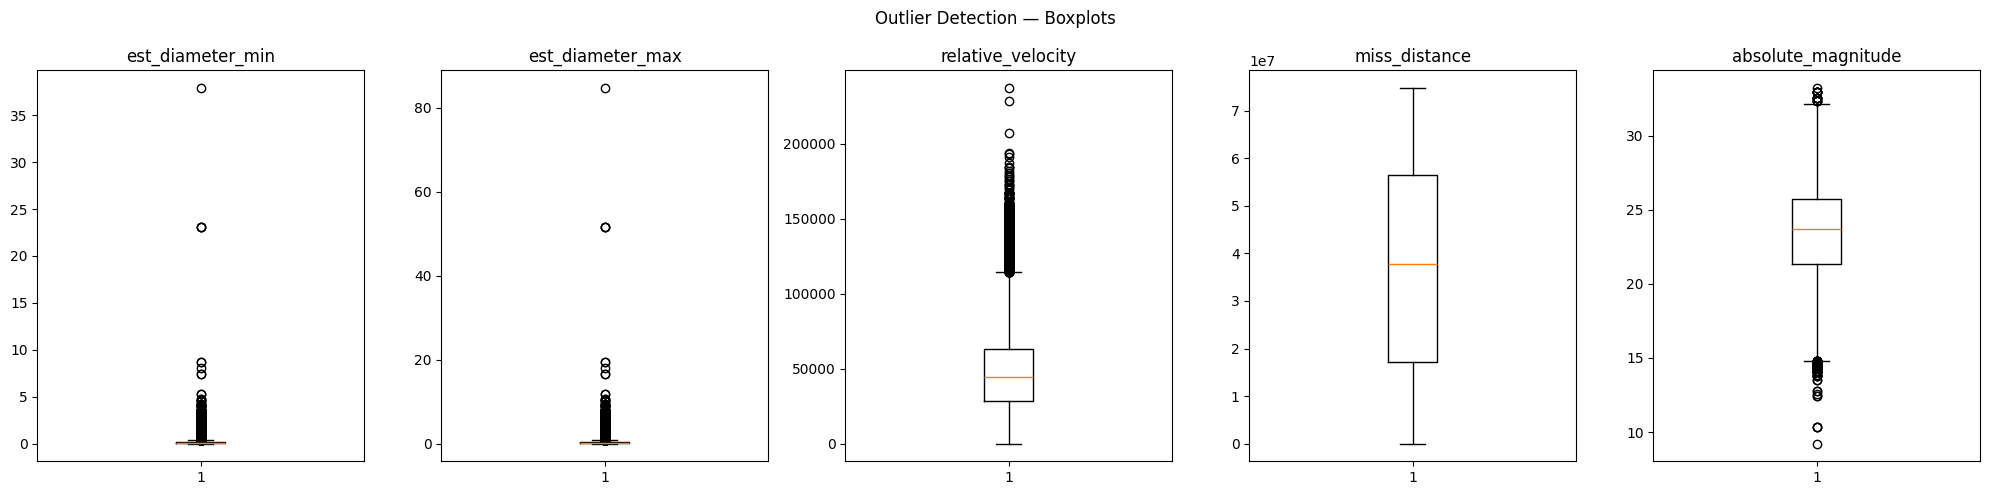

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df_clean[col])
    axes[i].set_title(col)

plt.suptitle('Outlier Detection — Boxplots')
plt.tight_layout()
plt.show()

In [47]:
outlier_summary = {}

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_pct = outliers / len(df_clean) * 100
    outlier_summary[col] = outliers
    print(f'  {col}: {outliers} outliers ({outlier_pct:.2f}%)')

  est_diameter_min: 8306 outliers (9.14%)
  est_diameter_max: 8306 outliers (9.14%)
  relative_velocity: 1573 outliers (1.73%)
  miss_distance: 0 outliers (0.00%)
  absolute_magnitude: 101 outliers (0.11%)


In [48]:
outlier_summary

{'est_diameter_min': np.int64(8306),
 'est_diameter_max': np.int64(8306),
 'relative_velocity': np.int64(1573),
 'miss_distance': np.int64(0),
 'absolute_magnitude': np.int64(101)}

In [49]:
df_processed = df_clean.copy()

for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_processed[col] = df_processed[col].clip(lower=lower, upper=upper)

In [50]:
df_processed.shape

(90829, 6)

## Step 6: Feature Scaling

In [52]:
X = df_processed.drop(columns=['hazardous'])
y = df_processed['hazardous']

In [53]:
X.shape

(90829, 5)

In [54]:
y.shape

(90829,)

In [131]:
df_processed.to_csv('sprint1.csv')

## Step 7: Train-Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((72663, 5), (18166, 5), (72663,), (18166,))

In [57]:
scaler = StandardScaler()

In [58]:
X_train_scaled = scaler.fit_transform(X_train)

In [59]:
X_train_scaled

array([[-0.74679691, -0.74679691,  0.08131269, -1.36658496,  0.75074771],
       [-0.80979067, -0.80979067, -0.03220487,  0.72186099,  1.06138337],
       [-0.04385342, -0.04385342,  0.17540828, -0.38786429, -0.42276478],
       ...,
       [ 0.29415524,  0.29415524,  0.29166312,  0.18307785, -0.6643703 ],
       [ 1.01158907,  1.01158907,  1.05543701, -0.74058868, -1.00952103],
       [ 0.47588145,  0.47588145,  0.96784764, -0.63804752, -0.76791552]],
      shape=(72663, 5))

In [60]:
X_test_scaled  = scaler.transform(X_test)

In [61]:
X_test_scaled

array([[ 1.01158907,  1.01158907,  1.71232968,  0.25414408, -1.00952103],
       [-0.75515273, -0.75515273, -0.84505809,  1.54071378,  0.78526278],
       [ 0.47588145,  0.47588145, -0.77702137,  1.54233546, -0.76791552],
       ...,
       [ 1.87754198,  1.87754198, -1.14256882,  0.53852024, -1.28564161],
       [-0.59461582, -0.59461582,  0.94691296,  0.99118745,  0.30205175],
       [ 0.40016548,  0.40016548,  0.04119014, -0.00345107, -0.72649743]],
      shape=(18166, 5))

In [62]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)

In [63]:
X_train_scaled

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
0,-0.746797,-0.746797,0.081313,-1.366585,0.750748
1,-0.809791,-0.809791,-0.032205,0.721861,1.061383
2,-0.043853,-0.043853,0.175408,-0.387864,-0.422765
3,-0.791618,-0.791618,-0.962045,-1.481082,0.957838
4,-0.345361,-0.345361,-0.128722,-0.258596,-0.112129
...,...,...,...,...,...
72658,-0.526284,-0.526284,-1.021561,-0.783089,0.163991
72659,-0.755153,-0.755153,-1.351513,-1.351513,0.785263
72660,0.294155,0.294155,0.291663,0.183078,-0.664370
72661,1.011589,1.011589,1.055437,-0.740589,-1.009521


In [64]:
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

In [65]:
X_test_scaled

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
0,1.011589,1.011589,1.712330,0.254144,-1.009521
1,-0.755153,-0.755153,-0.845058,1.540714,0.785263
2,0.475881,0.475881,-0.777021,1.542335,-0.767916
3,-0.839404,-0.839404,-0.715383,-1.143296,1.268474
4,-0.843592,-0.843592,-0.662357,-1.481099,1.302989
...,...,...,...,...,...
18161,-0.676177,-0.676177,0.159051,-1.072050,0.509142
18162,-0.804010,-0.804010,-0.893438,1.217498,1.026868
18163,1.877542,1.877542,-1.142569,0.538520,-1.285642
18164,-0.594616,-0.594616,0.946913,0.991187,0.302052


In [66]:
# Verify scaling
X_train_scaled.mean().round(6),X_train_scaled.std().round(6)

(est_diameter_min     -0.0
 est_diameter_max     -0.0
 relative_velocity     0.0
 miss_distance         0.0
 absolute_magnitude    0.0
 dtype: float64,
 est_diameter_min      1.000007
 est_diameter_max      1.000007
 relative_velocity     1.000007
 miss_distance         1.000007
 absolute_magnitude    1.000007
 dtype: float64)

## Sprint 1 — Final Summary

In [128]:
print('=' * 60)
print('       SPRINT 1 DELIVERABLES SUMMARY')
print('=' * 60)
print(f'Original dataset shape         : {df.shape}')
print(f'Cleaned dataset shape          : {df_processed.shape}')
print(f'Features used                  : {X.columns.tolist()}')
print(f'Target variable                : hazardous (0/1)')
print(f'Training samples               : {X_train_scaled.shape[0]}')
print(f'Test samples                   : {X_test_scaled.shape[0]}')
print(f'Missing values                 : None')
print(f'Duplicates removed             : {before - after}')
print(f'Outlier treatment              : IQR Capping (Winsorization)')
print(f'Encoding                       : Boolean → int (0/1)')
print(f'Scaling                        : StandardScaler (fit on train only)')
print(f'Class imbalance ratio          : ~90% Non-Hazardous / 10% Hazardous')
print('=' * 60)

       SPRINT 1 DELIVERABLES SUMMARY
Original dataset shape         : (90836, 10)
Cleaned dataset shape          : (90829, 6)
Features used                  : ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
Target variable                : hazardous (0/1)
Training samples               : 72663
Test samples                   : 18166
Missing values                 : None
Duplicates removed             : 7
Outlier treatment              : IQR Capping (Winsorization)
Encoding                       : Boolean → int (0/1)
Scaling                        : StandardScaler (fit on train only)
Class imbalance ratio          : ~90% Non-Hazardous / 10% Hazardous
